# Tracking a moving target

A target moves in a plane with roughly constant velocity, and a sensor reports its position
with noise. This tutorial builds a linear Kalman filter for it, smooths the result, checks
that the filter's uncertainty is honest, and runs the same filter on the JAX backend.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from kalman_py import KalmanFilter
from kalman_py.diagnostics import consistency_check, nees
from kalman_py.plotting import plot_consistency, plot_estimates

rng = np.random.default_rng(42)

## The model

The state is position and velocity, `(px, py, vx, vy)`. Between measurements the velocity
changes by random accelerations of spectral density `q`, which gives the standard
discretized process noise `Q`. The sensor measures position only, with standard deviation
3 m.

In [2]:
dt, q, sigma = 1.0, 0.05, 3.0

F = np.eye(4)
F[0, 2] = F[1, 3] = dt
H = np.array([[1.0, 0, 0, 0], [0, 1.0, 0, 0]])
block = q * np.array([[dt**3 / 3, dt**2 / 2], [dt**2 / 2, dt]])
Q = np.zeros((4, 4))
Q[np.ix_([0, 2], [0, 2])] = block
Q[np.ix_([1, 3], [1, 3])] = block
R = sigma**2 * np.eye(2)

x0 = np.array([0.0, 0.0, 5.0, 2.0])  # prior mean: before the first prediction
P0 = np.diag([10.0, 10.0, 4.0, 4.0]) ** 2


def simulate(
    steps: int, rng: np.random.Generator
) -> tuple[np.ndarray, np.ndarray]:
    """True states and measurements, drawn from exactly the model above."""
    x = rng.multivariate_normal(x0, P0)
    truth, zs = np.empty((steps, 4)), np.empty((steps, 2))
    for k in range(steps):
        x = F @ x + rng.multivariate_normal(np.zeros(4), Q)
        truth[k] = x
        zs[k] = H @ x + rng.multivariate_normal(np.zeros(2), R)
    return truth, zs


truth, zs = simulate(150, rng)

## Filter and smooth

`filter` runs the whole sequence; `smooth` then refines every estimate with the measurements
that came after it (Rauch-Tung-Striebel). The filter needs only the model.

In [3]:
kf = KalmanFilter(F, H, Q, R, x0, P0)
filtered = kf.filter(zs)
smoothed = kf.smooth(filtered)


def position_rmse(positions: np.ndarray) -> float:
    return float(
        np.sqrt(np.mean(np.sum((positions - truth[:, :2]) ** 2, axis=1)))
    )


print(f"raw measurements  {position_rmse(zs):5.2f} m")
print(f"filtered          {position_rmse(filtered.means[:, :2]):5.2f} m")
print(f"smoothed          {position_rmse(smoothed.means[:, :2]):5.2f} m")

raw measurements   4.08 m
filtered           2.19 m
smoothed           1.11 m


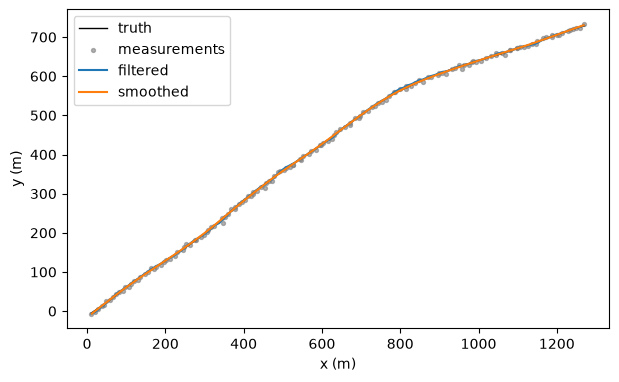

In [4]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(truth[:, 0], truth[:, 1], color="black", linewidth=1, label="truth")
ax.scatter(
    zs[:, 0], zs[:, 1], s=8, color="gray", alpha=0.6, label="measurements"
)
ax.plot(filtered.means[:, 0], filtered.means[:, 1], label="filtered")
ax.plot(smoothed.means[:, 0], smoothed.means[:, 1], label="smoothed")
ax.set_xlabel("x (m)")
ax.set_ylabel("y (m)")
ax.set_aspect("equal")
ax.legend()
plt.show()

`plot_estimates` shows each state with a ±2σ band. The velocity is never measured directly,
yet the filter recovers it from successive positions.

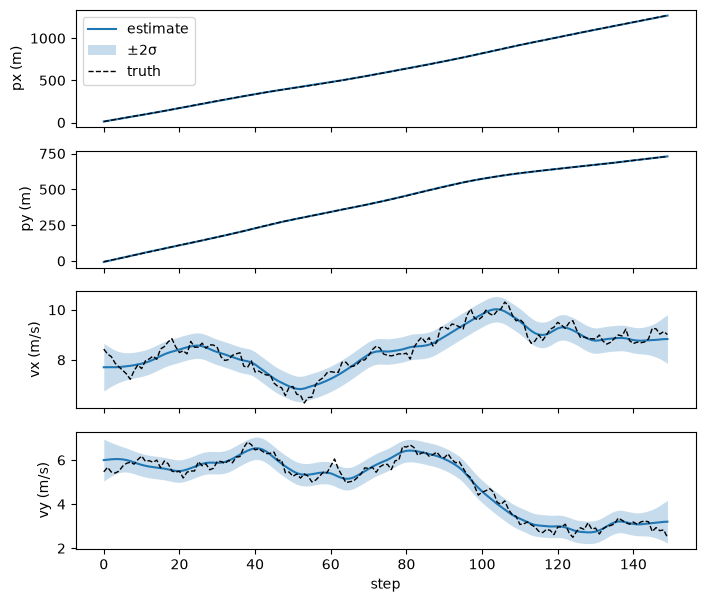

In [5]:
axes = plot_estimates(
    smoothed, truth=truth, labels=["px (m)", "py (m)", "vx (m/s)", "vy (m/s)"]
)
axes[0].figure.set_size_inches(8, 7)
plt.show()

## Is the filter honest about its uncertainty?

A consistent filter's errors match its covariance: the normalized estimation error squared
(NEES) averages the state dimension, 4, and the normalized innovation squared (NIS) averages
the measurement dimension, 2. Over many Monte Carlo runs the per-step averages should stay
inside their 95% χ² bounds about 95% of the time.

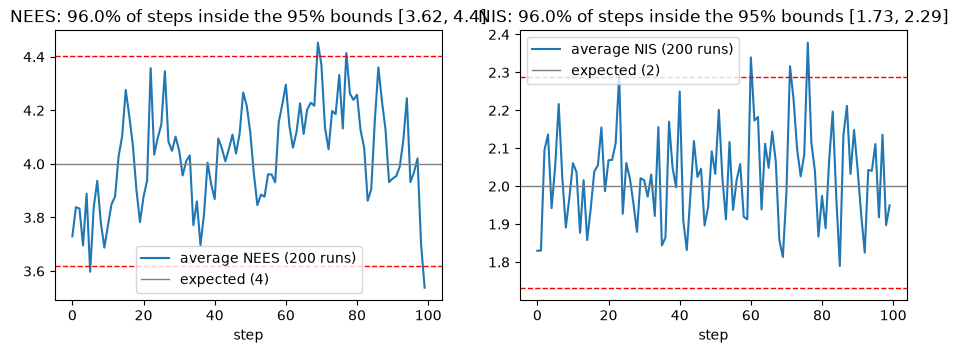

time-averaged NEES 4.03 (expected 4)
time-averaged NIS  2.03 (expected 2)


In [6]:
runs = [simulate(100, rng) for _ in range(200)]
nees_runs, nis_runs = [], []
for run_truth, run_zs in runs:
    result = kf.filter(run_zs)
    nees_runs.append(nees(run_truth, result.means, result.covs))
    nis_runs.append(result.nis)

anees = consistency_check(np.array(nees_runs), dof=4)
anis = consistency_check(np.array(nis_runs), dof=2)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.5))
plot_consistency(anees, name="NEES", ax=ax1)
plot_consistency(anis, name="NIS", ax=ax2)
plt.show()
print(f"time-averaged NEES {anees.average.mean():.2f} (expected 4)")
print(f"time-averaged NIS  {anis.average.mean():.2f} (expected 2)")

NEES is correlated from step to step, so its excursions cluster; the time-averaged value is
the more robust check. A filter told the process noise is 10× smaller than it is fails this
test clearly:

In [7]:
overconfident = KalmanFilter(F, H, Q / 10, R, x0, P0)
bad = []
for run_truth, run_zs in runs:
    result = overconfident.filter(run_zs)
    bad.append(nees(run_truth, result.means, result.covs))
bad_average = consistency_check(np.array(bad), dof=4).average.mean()
print(f"time-averaged NEES with Q/10: {bad_average:.1f}")

time-averaged NEES with Q/10: 19.4


## The JAX backend

The same filter compiles to a single XLA loop with `backend="jax"`. The results match the
NumPy backend to rounding error; the first call includes compilation, later calls with the
same shapes reuse it.

In [8]:
import time

import jax

jax.config.update("jax_enable_x64", True)  # float64, like the NumPy backend

long_truth, long_zs = simulate(10_000, rng)
jax_result = kf.filter(long_zs, backend="jax")  # compiles
start = time.perf_counter()
jax_result = kf.filter(long_zs, backend="jax")
jax.block_until_ready(jax_result.means)
jax_time = time.perf_counter() - start

start = time.perf_counter()
numpy_result = kf.filter(long_zs)
numpy_time = time.perf_counter() - start

difference = np.abs(np.asarray(jax_result.means) - numpy_result.means).max()
print(f"largest difference: {difference:.1e}")
print(f"JAX   {jax_time / 10_000 * 1e6:.2f} µs/step")
print(f"NumPy {numpy_time / 10_000 * 1e6:.2f} µs/step")

largest difference: 5.5e-12
JAX   1.60 µs/step
NumPy 15.07 µs/step
